In [1]:
import sys
dir_path = '/Users/henry/Desktop/SWxResearch/KpAp-forecast-verification'
if dir_path not in sys.path:
    sys.path.insert(0, dir_path)

import os
os.chdir(dir_path)

import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import h5py


In [2]:
# Function to take two dataframes and return two new dataframes that only contain shared dates with no nans

def df_shared_dates(df1, df2):

    df1 = df1.dropna().copy()
    df2 = df2.dropna().copy()

    df1['date'] = pd.to_datetime(df1['date'])
    df2['date'] = pd.to_datetime(df2['date'])

    shared_dates = set(df1['date']) & set(df2['date'])

    df1_shared_dates = df1[df1['date'].isin(shared_dates)].reset_index(drop=True)
    df2_shared_dates = df2[df2['date'].isin(shared_dates)].reset_index(drop=True)

    return df1_shared_dates, df2_shared_dates

def make_Ap_storage_list():

    return [[] for i in range(3)]

def make_Kp_storage_list():

    return [[] for i in range(24)]

def forecast_difference(df1, df2):

    df_diff = df1 - df2
    df_diff['date'] = df1['date']

    return df_diff

def create_3day_Ap_from_real_vals():

    df_real_Ap = pd.read_csv('processed_data/daily_Ap.csv')

    real_Ap_lists = make_Ap_storage_list()

    Ap_values = df_real_Ap['Ap'].values
    for i in range(len(df_real_Ap['Datetime'])-3):
        for j in range(len(real_Ap_lists)):
            real_Ap_lists[j].append(Ap_values[i+j+1])

    Ap_dict = {'date': df_real_Ap['Datetime'][:-3]}
    for i in range(len(real_Ap_lists)):
        Ap_dict[f'{i+1}dAp'] = np.array(real_Ap_lists[i], dtype=int)

    df_real_Ap_3day = pd.DataFrame(Ap_dict)

    return df_real_Ap_3day

def create_3day_Kp_from_real_vals():

    df_real_Kp = pd.read_csv('processed_data/3hour_Kp.csv')

    real_Kp_lists = make_Kp_storage_list()

    Kp_values = df_real_Kp['Kp'].values
    for i in range(len(df_real_Kp['Datetime'])-24):
        for j in range(len(real_Kp_lists)):
            real_Kp_lists[j].append(Kp_values[i+j+1])

    Kp_dict = {'date': df_real_Kp['Datetime'][:-24]}
    for i in range(len(real_Kp_lists)):
        Kp_dict[f'{3*(i+1)}hrKp'] = np.array(real_Kp_lists[i], dtype=float)
    
    df_real_Kp_3day = pd.DataFrame(Kp_dict)

    df_real_Kp_3day_filtered = df_real_Kp_3day[df_real_Kp_3day.index % 8 == 0].copy()

    df_real_Kp_3day_filtered['date'] = df_real_Kp_3day_filtered['date'].str[:-9]
    
    return df_real_Kp_3day_filtered

def create_3day_Ap_persistence_forecast():

    df_real_Ap = pd.read_csv('processed_data/daily_Ap.csv')

    persistence_Ap_lists = make_Ap_storage_list()

    Ap_values = df_real_Ap['Ap'].values
    for i in range(len(df_real_Ap['Datetime'])):
        for j in range(len(persistence_Ap_lists)):
            persistence_Ap_lists[j].append(Ap_values[i])

    Ap_dict = {'date': df_real_Ap['Datetime']}
    for i in range(len(persistence_Ap_lists)):
        Ap_dict[f'{i+1}dAp'] = np.array(persistence_Ap_lists[i], dtype=int)

    df_persistence_Ap_3day = pd.DataFrame(Ap_dict)

    return df_persistence_Ap_3day

def create_3day_Ap_recurrence_forecast():

    df_real_Ap = pd.read_csv('processed_data/daily_Ap.csv')

    recurrence_Ap_lists = make_Ap_storage_list()

    Ap_values = df_real_Ap['Ap'].values
    for i in range(len(df_real_Ap['Datetime'][27:])):
        for j in range(len(recurrence_Ap_lists)):
            recurrence_Ap_lists[j].append(Ap_values[i+j])

    Ap_dict = {'date': df_real_Ap['Datetime'][27:]}
    for i in range(len(recurrence_Ap_lists)):
        Ap_dict[f'{i+1}dAp'] = np.array(recurrence_Ap_lists[i], dtype=int)

    df_recurrence_Ap_3day = pd.DataFrame(Ap_dict)

    return df_recurrence_Ap_3day

def create_3day_Kp_persistence_forecast():

    df_real_Kp = pd.read_csv('processed_data/3hour_Kp.csv')

    persistence_Kp_lists = make_Kp_storage_list()

    Kp_values = df_real_Kp['Kp'].values
    for i in range(len(df_real_Kp['Datetime'])):
        for j in range(len(persistence_Kp_lists)):
            persistence_Kp_lists[j].append(Kp_values[i])

    Kp_dict = {'date': df_real_Kp['Datetime']}
    for i in range(len(persistence_Kp_lists)):
        Kp_dict[f'{3*(i+1)}hrKp'] = np.array(persistence_Kp_lists[i], dtype=float)

    df_persistence_Kp_3day = pd.DataFrame(Kp_dict)

    df_persistence_Kp_3day_filtered = df_persistence_Kp_3day[df_persistence_Kp_3day.index % 8 == 0].copy()

    df_persistence_Kp_3day_filtered['date'] = df_persistence_Kp_3day_filtered['date'].str[:-9]

    return df_persistence_Kp_3day_filtered

def create_3day_Kp_recurrence_forecast():

    df_real_Kp = pd.read_csv('processed_data/3hour_Kp.csv')

    recurrence_Kp_lists = make_Kp_storage_list()

    Kp_values = df_real_Kp['Kp'].values
    for i in range(len(df_real_Kp['Datetime'][27*8:])):
        for j in range(len(recurrence_Kp_lists)):
            recurrence_Kp_lists[j].append(Kp_values[i+j])

    Kp_dict = {'date': df_real_Kp['Datetime'][27*8:]}
    for i in range(len(recurrence_Kp_lists)):
        Kp_dict[f'{3*(i+1)}hrKp'] = np.array(recurrence_Kp_lists[i], dtype=float)

    df_persistence_Kp_3day = pd.DataFrame(Kp_dict)

    df_persistence_Kp_3day_filtered = df_persistence_Kp_3day[df_persistence_Kp_3day.index % 8 == 0].copy()

    df_persistence_Kp_3day_filtered['date'] = df_persistence_Kp_3day_filtered['date'].str[:-9]

    return df_persistence_Kp_3day_filtered

def total_forecast_differences(df1, df2):

    df1_shared_dates, df2_shared_dates = df_shared_dates(df1=df1, df2=df2)
    df_diff = forecast_difference(df1=df1_shared_dates, df2=df2_shared_dates)
    df_keys = df_diff.keys()

    diff_dict = {}
    for i in range(1, len(df_keys)):
        diff_dict[df_keys[i]] = [df_diff[df_keys[i]].sum()]

    total_differences = pd.DataFrame({diff_dict})
    
    return total_differences

def forecast_RMSE(df_forecast, df_real_vals):
    
    df_forecast_shared_dates, df_real_vals_shared_dates = df_shared_dates(df1=df_forecast, df2=df_real_vals)
    df_err = forecast_difference(df1=df_forecast_shared_dates, df2=df_real_vals_shared_dates)

    df_sq_err = df_err.copy()
    num_cols = df_sq_err.select_dtypes(include='number').columns
    df_sq_err[num_cols] = df_sq_err[num_cols] ** 2


    df_keys = df_sq_err.keys()
    N = len(df_sq_err[df_keys[1]])

    rmse_dict = {}
    for i in range(1, len(df_keys)):
        rmse_dict[df_keys[i]] = [np.sqrt(df_sq_err[df_keys[i]].sum() / N)]

    RMSE = pd.DataFrame(rmse_dict)
    
    return RMSE

def Ap_RMSE_plot(df_RMSE_Ap, report):

    RMSE_arr = df_RMSE_Ap.to_numpy()[0]
    RMSE_Ap_x_vals = [i+1 for i in range(len(RMSE_arr))]
    
    plt.plot(RMSE_Ap_x_vals, RMSE_arr, color='orange', marker='o')
    plt.title(f'{report} Ap RMSE vs. Days Since Forecast')
    plt.xlabel('Days Since Forecast')
    plt.ylabel('RMSE')
    plt.xticks(RMSE_Ap_x_vals)
    plt.show()

def Kp_RMSE_plot(df_RMSE_Kp, report):

    RMSE_arr = df_RMSE_Kp.to_numpy()[0]
    RMSE_Kp_x_vals = [3*(i+1) for i in range(len(RMSE_arr))]
    
    plt.plot(RMSE_Kp_x_vals, RMSE_arr, color='orange', marker='o')
    plt.title(f'{report} Kp RMSE vs. Hours Since Forecast')
    plt.xlabel('Hours Since Forecast')
    plt.ylabel('RMSE')
    plt.xticks(RMSE_Kp_x_vals)
    plt.show()



In [3]:
import unittest
import pandas.testing as pdt

class TestDfSharedDates(unittest.TestCase):

    def test_correct_ans(self):

        df1 = pd.DataFrame({'date': ['2022-11-11', '2022-12-12'],
                            'vals': [0, 1]})
        df2 = pd.DataFrame({'date': ['2022-11-11', '2022-09-09'],
                            'vals': [2, 3]})
        
        expected_df1 = pd.DataFrame({'date': [dt.datetime(2022, 11, 11)],
                                      'vals': [0]})
        expected_df2 = pd.DataFrame({'date': [dt.datetime(2022, 11, 11)],
                                      'vals': [2]})
        
        result_df1, result_df2 = df_shared_dates(df1=df1, df2=df2)

        pdt.assert_frame_equal(result_df1, expected_df1)
        pdt.assert_frame_equal(result_df2, expected_df2)

class TestMakeApStorageList(unittest.TestCase):

    def test_correct_length(self):

        expected_len = 3
        result_len = len(make_Ap_storage_list())

        self.assertEqual(result_len, expected_len)

class TestMakeKpStorageList(unittest.TestCase):

    def test_correct_length(self):

        expected_len = 24
        result_len = len(make_Kp_storage_list())

        self.assertEqual(result_len, expected_len)

class TestForecastDifference(unittest.TestCase):

    def test_correct_vals(self):

        df1 = pd.DataFrame({'date': [dt.datetime(2022, 11, 11), dt.datetime(2022, 12, 12)],
                            'vals1': [0, 1],
                            'vals2': [10, 11]})
        df2 = pd.DataFrame({'date': [dt.datetime(2022, 11, 11), dt.datetime(2022, 12, 12)],
                            'vals1': [2, 3],
                            'vals2': [20, 21]})
        
        expected_df = pd.DataFrame({'date': [dt.datetime(2022, 11, 11), dt.datetime(2022, 12, 12)],
                                     'vals1': [-2, -2],
                                     'vals2': [-10, -10]})
        
        result_df = forecast_difference(df1=df1, df2=df2)

        pdt.assert_frame_equal(result_df, expected_df)

class TestCreate3dayApFromRealVals(unittest.TestCase):

    def test_correct_vals_subset(self):

        result = create_3day_Ap_from_real_vals()

        expected_19320101 = [26, 11, 4]
        expected_20120918 = [14, 10, 6]
        expected_20191029 = [7, 6, 3]

        result_19320101 = result.loc[result['date'] == '1932-01-01'].values[0][1:].tolist()
        result_20120918 = result.loc[result['date'] == '2012-09-18'].values[0][1:].tolist()
        result_20191029 = result.loc[result['date'] == '2019-10-29'].values[0][1:].tolist()

        self.assertEqual(result_19320101, expected_19320101)
        self.assertEqual(result_20120918, expected_20120918)
        self.assertEqual(result_20191029, expected_20191029)

class TestCreate3dayKpFromRealVals(unittest.TestCase):

    def test_correct_vals_subset(self):

        result = create_3day_Kp_from_real_vals()

        expected_19320101 = [2.667, 2.333, 2.667, 3.333, 2.667, 3.333, 3.333, 3.667, 3.667, 3.333, 3.667, 3.333, 4.667, 3.0, 5.0, 3.333, 3.333, 3.0, 1.0, 2.333, 1.667, 2.667, 2.0, 2.0]
        expected_20120918 = [3.333, 2.0, 1.667, 2.333, 2.667, 0.333, 1.0, 1.0, 2.333, 0.667, 1.333, 1.667, 3.667, 3.667, 4.667, 3.333, 2.0, 3.0, 2.333, 2.0, 2.0, 2.0, 1.667, 1.333]
        expected_20191029 = [3.0, 0.667, 0.0, 0.667, 2.667, 2.333, 1.333, 1.0, 1.333, 1.0, 1.0, 2.333, 2.333, 2.333, 2.333, 3.667, 0.333, 0.333, 1.333, 0.0, 0.333, 2.667, 1.667, 1.333]
        
        result_19320101 = result.loc[result['date'] == '1932-01-01'].values[0][1:].tolist()
        result_20120918 = result.loc[result['date'] == '2012-09-18'].values[0][1:].tolist()
        result_20191029 = result.loc[result['date'] == '2019-10-29'].values[0][1:].tolist()

        self.assertEqual(result_19320101, expected_19320101)
        self.assertEqual(result_20120918, expected_20120918)
        self.assertEqual(result_20191029, expected_20191029)

class TestForecastRMSE(unittest.TestCase):

    def test_correct_vals(self):
        
        df_forecast = pd.DataFrame({'date': [dt.datetime(2000, 11, 11), dt.datetime(2000, 11, 12)],
                                    'val1': [1, 1],
                                    'val2': [2, 2]})
        
        df_real = pd.DataFrame({'date': [dt.datetime(2000, 11, 11), dt.datetime(2000, 11, 12)],
                                    'val1': [3, 3],
                                    'val2': [1, 1]})
        
        result_RMSE = forecast_RMSE(df_forecast=df_forecast, df_real_vals=df_real)

        expected_RMSE = pd.DataFrame({'val1': [2.0],
                                      'val2': [1.0]})
        pdt.assert_frame_equal(result_RMSE, expected_RMSE)

class TestCreate3DayApPersistenceForecast(unittest.TestCase):

    def test_correct_vals(self):

        result = create_3day_Ap_persistence_forecast()

        expected_19320101 = [15, 15, 15]
        expected_20120918 = [9, 9, 9]
        expected_20191029 = [7, 7, 7]

        result_19320101 = result.loc[result['date'] == '1932-01-01'].values[0][1:].tolist()
        result_20120918 = result.loc[result['date'] == '2012-09-18'].values[0][1:].tolist()
        result_20191029 = result.loc[result['date'] == '2019-10-29'].values[0][1:].tolist()

        self.assertEqual(result_19320101, expected_19320101)
        self.assertEqual(result_20120918, expected_20120918)
        self.assertEqual(result_20191029, expected_20191029)

class TestCreate3DayKpPersistenceForecast(unittest.TestCase):

    def test_correct_vals(self):

        result = create_3day_Kp_persistence_forecast()

        expected_19320101 = [3.333 for i in range(24)]
        expected_20120918 = [3.0 for i in range(24)]
        expected_20191029 = [2.667 for i in range(24)]

        result_19320101 = result.loc[result['date'] == '1932-01-01'].values[0][1:].tolist()
        result_20120918 = result.loc[result['date'] == '2012-09-18'].values[0][1:].tolist()
        result_20191029 = result.loc[result['date'] == '2019-10-29'].values[0][1:].tolist()

        self.assertEqual(result_19320101, expected_19320101)
        self.assertEqual(result_20120918, expected_20120918)
        self.assertEqual(result_20191029, expected_20191029)
    
class TestCreate3DayApRecurrenceForecast(unittest.TestCase):

    def test_correct_vals(self):
        
        result = create_3day_Ap_recurrence_forecast()

        expected_19320128 = [15, 26, 11]
        expected_20120918 = [5, 9, 7]
        expected_20191029 = [6, 4, 6]

        result_19320128 = result.loc[result['date'] == '1932-01-28'].values[0][1:].tolist()
        result_20120918 = result.loc[result['date'] == '2012-09-18'].values[0][1:].tolist()
        result_20191029 = result.loc[result['date'] == '2019-10-29'].values[0][1:].tolist()

        self.assertEqual(result_19320128, expected_19320128)
        self.assertEqual(result_20120918, expected_20120918)
        self.assertEqual(result_20191029, expected_20191029)


class TestCreate3DayKpRecurrenceForecast(unittest.TestCase):

    def test_correct_vals(self):

        result = create_3day_Kp_recurrence_forecast()

        expected_19320128 = [3.333, 2.667, 2.333, 2.667, 3.333, 2.667, 3.333, 3.333, 3.667, 3.667, 3.333, 3.667, 3.333, 4.667, 3.0, 5.0, 3.333, 3.333, 3.0, 1.0, 2.333, 1.667, 2.667, 2.0]
        expected_20120918 = [1.0, 1.333, 0.333, 1.0, 2.333, 1.333, 1.0, 2.333, 3.0, 2.0, 2.0, 2.0, 2.0, 2.333, 3.0, 0.667, 2.333, 2.0, 1.333, 1.333, 2.0, 1.333, 2.0, 2.667]
        expected_20191029 = [3.0, 0.0, 0.0, 2.0, 2.667, 1.0, 1.0, 2.333, 1.667, 1.333, 1.0, 1.0, 0.333, 0.667, 1.333, 1.0, 1.0, 1.667, 2.667, 1.667, 2.0, 2.0, 1.667, 0.667]

        result_19320128 = result.loc[result['date'] == '1932-01-28'].values[0][1:].tolist()
        result_20120918 = result.loc[result['date'] == '2012-09-18'].values[0][1:].tolist()
        result_20191029 = result.loc[result['date'] == '2019-10-29'].values[0][1:].tolist()

        self.assertEqual(result_19320128, expected_19320128)
        self.assertEqual(result_20120918, expected_20120918)
        self.assertEqual(result_20191029, expected_20191029)

unittest.main(argv=[''], exit=False, verbosity=2)

test_correct_vals (__main__.TestCreate3DayApPersistenceForecast.test_correct_vals) ... ok
test_correct_vals (__main__.TestCreate3DayApRecurrenceForecast.test_correct_vals) ... ok
test_correct_vals (__main__.TestCreate3DayKpPersistenceForecast.test_correct_vals) ... ok
test_correct_vals (__main__.TestCreate3DayKpRecurrenceForecast.test_correct_vals) ... ok
test_correct_vals_subset (__main__.TestCreate3dayApFromRealVals.test_correct_vals_subset) ... ok
test_correct_vals_subset (__main__.TestCreate3dayKpFromRealVals.test_correct_vals_subset) ... ok
test_correct_ans (__main__.TestDfSharedDates.test_correct_ans) ... ok
test_correct_vals (__main__.TestForecastDifference.test_correct_vals) ... ok
test_correct_vals (__main__.TestForecastRMSE.test_correct_vals) ... ok
test_correct_length (__main__.TestMakeApStorageList.test_correct_length) ... ok
test_correct_length (__main__.TestMakeKpStorageList.test_correct_length) ... ok

---------------------------------------------------------------------

## Comparison of Ap forecasts from daypre and geomag_forecast

In [ ]:
df_geomag_forecast_Ap = pd.read_csv('processed_data/geomag_forecast_3dayAp.csv')

In [39]:
daypre_geomag_forecast_Ap_diff = total_forecast_differences(df1=df_daypre_Ap, df2=df_geomag_forecast_Ap)
display(daypre_geomag_forecast_Ap_diff)

/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_56332/2285473201.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date'] = pd.to_datetime(df1['date'])
/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_56332/2285473201.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['date'] = pd.to_datetime(df2['date'])


,1dAp,2dAp,3dAp
0,0.0,0.0,0.0


Ap forecasts from Ap and daypre are identical during period where both forecasts are published

## RMSE of Ap Forecast

/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_64646/4217328024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date'] = pd.to_datetime(df1['date'])
/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_64646/4217328024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date'] = pd.to_datetime(df1['date'])


,1dAp,2dAp,3dAp
0,10.052502,10.219639,10.606342


,1dAp,2dAp,3dAp
0,14.465824,14.261555,15.236155


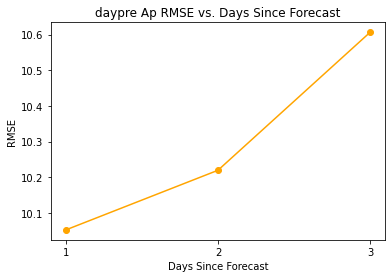

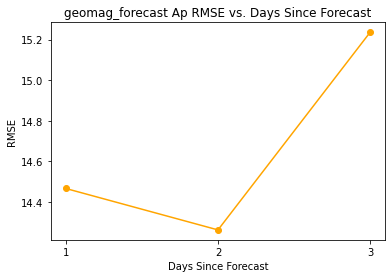

In [35]:
df_daypre_Ap = pd.read_csv('processed_data/daypre_3dayAp.csv')
df_geomag_forecast_Ap = pd.read_csv('processed_data/geomag_forecast_3dayAp.csv')

df_real_Ap = create_3day_Ap_from_real_vals()

df_daypre_RMSE_Ap = forecast_RMSE(df_forecast=df_daypre_Ap, df_real_vals=df_real_Ap)
df_geomag_forecast_RMSE_Ap = forecast_RMSE(df_forecast=df_geomag_forecast_Ap, df_real_vals=df_real_Ap)

display(df_daypre_RMSE_Ap)
display(df_geomag_forecast_RMSE_Ap)

Ap_RMSE_plot(df_RMSE_Ap=df_daypre_RMSE_Ap, report='daypre')
Ap_RMSE_plot(df_RMSE_Ap=df_geomag_forecast_RMSE_Ap, report='geomag_forecast')

RMSE increases slightly over days of forecast. A bit suprising it does not increase more but if forecast is dominated by persistance and quiet times then it makes sense it would perform reasonably well a few days out. 

Lower RMSE for daypre. Maybe it is the case that more daypre forecasts are during quiet time due to less active solar periods.

## RMSE of Kp Forecast

In [41]:
df_real_Kp = create_3day_Kp_from_real_vals()

/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_13057/3251978305.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_real_Kp_3day_filtered['date'] = df_real_Kp_3day_filtered['date'].str[:-9]


/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_64646/4217328024.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date'] = pd.to_datetime(df1['date'])


,3hrKp,6hrKp,9hrKp,12hrKp,15hrKp,18hrKp,21hrKp,24hrKp,27hrKp,30hrKp,...,45hrKp,48hrKp,51hrKp,54hrKp,57hrKp,60hrKp,63hrKp,66hrKp,69hrKp,72hrKp
0,1.599887,1.678978,1.480057,1.315888,1.37879,1.51602,1.512765,1.653247,1.616459,1.665847,...,1.465909,1.600002,1.570013,1.554643,1.451601,1.365723,1.378168,1.435894,1.394857,1.510761


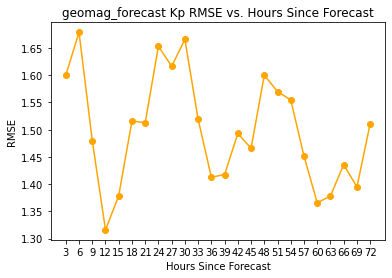

In [37]:
df_geomag_forecast_Kp = pd.read_csv('processed_data/geomag_forecast_3dayKp.csv')

df_geomag_forecast_RMSE_Kp = forecast_RMSE(df_forecast=df_geomag_forecast_Kp, df_real_vals=df_real_Kp)

display(df_geomag_forecast_RMSE_Kp)

Kp_RMSE_plot(df_RMSE_Kp=df_geomag_forecast_RMSE_Kp, report='geomag_forecast')

In [47]:
def get_storm_dates():

    with h5py.File('raw_data/storm_kp_swpc.h5', 'r') as f:
        
        storm_times = f['timestamp']
        
        storm_times = f['timestamp'][()]
        swpc_forecast = f['swpc_forecasts'][()]

        print(f.keys())
        print(f['event_idx'][()])

    storm_times_clean = [i.decode('utf-8') for i in storm_times]

    Kp_dict = {'date': storm_times_clean}
    for i in range(24):
        Kp_dict[f'{3*(i+1)}hrKp'] = np.array(swpc_forecast[:,i], dtype=float)

    storm_Kp_forecast = pd.DataFrame(Kp_dict)


    return storm_Kp_forecast


<KeysViewHDF5 ['actual_kp', 'event_idx', 'event_name', 'swpc_forecasts', 'timestamp']>
[14 14 14 ... 26 26 26]


/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_13057/3251978305.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date'] = pd.to_datetime(df1['date'])


,3hrKp,6hrKp,9hrKp,12hrKp,15hrKp,18hrKp,21hrKp,24hrKp,27hrKp,30hrKp,...,45hrKp,48hrKp,51hrKp,54hrKp,57hrKp,60hrKp,63hrKp,66hrKp,69hrKp,72hrKp
0,1.599887,1.678978,1.480057,1.315888,1.37879,1.51602,1.512765,1.653247,1.616459,1.665847,...,1.465909,1.600002,1.570013,1.554643,1.451601,1.365723,1.378168,1.435894,1.394857,1.510761


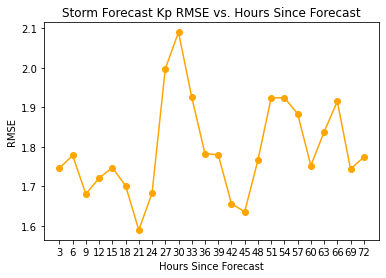

In [48]:
df_Kp_storm_forecast = get_storm_dates()

df_storm_forecast_RMSE_Kp = forecast_RMSE(df_forecast=df_Kp_storm_forecast, df_real_vals=df_real_Kp)

display(df_geomag_forecast_RMSE_Kp)

Kp_RMSE_plot(df_RMSE_Kp=df_storm_forecast_RMSE_Kp, report='Storm Forecast')

Somewhat inconsistent results here. Should check on this later. 

<KeysViewHDF5 ['actual_kp', 'event_idx', 'event_name', 'swpc_forecasts', 'timestamp']>
[14 14 14 ... 26 26 26]
134
[1.7 2.3 3.3 ... 2.  2.3 2.7]


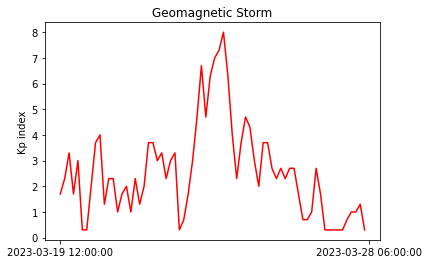

In [49]:
with h5py.File('raw_data/storm_kp_swpc.h5', 'r') as f:
        
    storm_times = f['timestamp']
    
    storm_times = f['timestamp'][()]
    swpc_forecast = f['swpc_forecasts'][()]
    actual_kp = f['actual_kp'][()]
    event_idx = f['event_idx'][()]

    print(f.keys())
    print(f['event_idx'][()])

storm_times_clean = [i.decode('utf-8') for i in storm_times]

Kp_dict = {'date': storm_times_clean}
for i in range(24):
    Kp_dict[f'{3*(i+1)}hrKp'] = np.array(swpc_forecast[:,i], dtype=float)

storm_Kp_forecast = pd.DataFrame(Kp_dict)

num_first_storm = list(event_idx).count(14)
print(num_first_storm)
print(actual_kp)

plt.plot(storm_times[:70], actual_kp[:70], color='red')
plt.title('Geomagnetic Storm')
plt.ylabel('Kp index')
plt.xticks([storm_times[0], storm_times[70]])
plt.show()


Look at Forecasts for storm

/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_13057/3251978305.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date'] = pd.to_datetime(df1['date'])
/var/folders/n5/9pgn92bx1ljbdy87trmzfqyc0000gn/T/ipykernel_13057/3251978305.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date'] = pd.to_datetime(df1['date'])


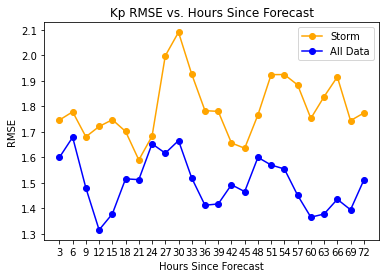

In [50]:
df_storm_forecast_RMSE_Kp = forecast_RMSE(df_forecast=df_Kp_storm_forecast, df_real_vals=df_real_Kp)
df_geomag_forecast_RMSE_Kp = forecast_RMSE(df_forecast=df_geomag_forecast_Kp, df_real_vals=df_real_Kp)

storm_RMSE_arr = df_storm_forecast_RMSE_Kp.to_numpy()[0]
normal_RMSE_arr = df_geomag_forecast_RMSE_Kp.to_numpy()[0]
RMSE_Kp_x_vals = [3*(i+1) for i in range(len(storm_RMSE_arr))]

plt.plot(RMSE_Kp_x_vals, storm_RMSE_arr, color='orange', marker='o', label='Storm')
plt.plot(RMSE_Kp_x_vals, normal_RMSE_arr, color='blue', marker='o', label='All Data')
plt.title(f'Kp RMSE vs. Hours Since Forecast')
plt.xlabel('Hours Since Forecast')
plt.ylabel('RMSE')
plt.xticks(RMSE_Kp_x_vals)
plt.legend()
plt.show()

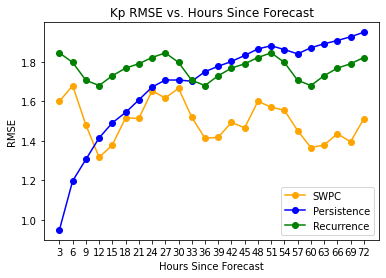

In [85]:
df_geomag_forecast_Kp = pd.read_csv('processed_data/geomag_forecast_3dayKp.csv')
df_geomag_forecast_RMSE_Kp = forecast_RMSE(df_forecast=df_geomag_forecast_Kp, df_real_vals=df_real_Kp)
df_persistence_Kp = create_3day_Kp_persistence_forecast()

df_persistence_RMSE_Kp = forecast_RMSE(df_forecast=df_persistence_Kp, df_real_vals=df_real_Kp)

df_recurrence_Kp = create_3day_Kp_recurrence_forecast()
df_recurrence_RMSE_Kp = forecast_RMSE(df_forecast=df_recurrence_Kp, df_real_vals=df_real_Kp)

normal_RMSE_arr = df_geomag_forecast_RMSE_Kp.to_numpy()[0]
persistence_RMSE_arr = df_persistence_RMSE_Kp.to_numpy()[0]
recurrence_RMSE_arr = df_recurrence_RMSE_Kp.to_numpy()[0]
RMSE_Kp_x_vals = [3*(i+1) for i in range(len(storm_RMSE_arr))]

plt.plot(RMSE_Kp_x_vals, normal_RMSE_arr, color='orange', marker='o', label='SWPC')
plt.plot(RMSE_Kp_x_vals, persistence_RMSE_arr, color='blue', marker='o', label='Persistence')
plt.plot(RMSE_Kp_x_vals, recurrence_RMSE_arr, color='green', marker='o', label='Recurrence')

plt.title(f'Kp RMSE vs. Hours Since Forecast')
plt.xlabel('Hours Since Forecast')
plt.ylabel('RMSE')
plt.xticks(RMSE_Kp_x_vals)
plt.legend()
plt.show()


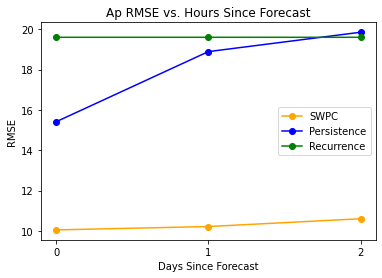

In [ ]:
df_real_Ap = create_3day_Ap_from_real_vals()

df_daypre_Ap = pd.read_csv('processed_data/daypre_3dayAp.csv')
df_daypre_RMSE_Ap = forecast_RMSE(df_forecast=df_daypre_Ap, df_real_vals=df_real_Ap)
df_persistence_Ap = create_3day_Ap_persistence_forecast()

df_persistence_RMSE_Ap = forecast_RMSE(df_forecast=df_persistence_Ap, df_real_vals=df_real_Ap)

df_recurrence_Ap = create_3day_Ap_recurrence_forecast()
df_recurrence_RMSE_Ap = forecast_RMSE(df_forecast=df_recurrence_Ap, df_real_vals=df_real_Ap)

normal_RMSE_arr = df_daypre_RMSE_Ap.to_numpy()[0]
persistence_RMSE_arr = df_persistence_RMSE_Ap.to_numpy()[0]
recurrence_RMSE_arr = df_recurrence_RMSE_Ap.to_numpy()[0]
RMSE_Ap_x_vals = [i for i in range(3)]

plt.plot(RMSE_Ap_x_vals, normal_RMSE_arr, color='orange', marker='o', label='SWPC')
plt.plot(RMSE_Ap_x_vals, persistence_RMSE_arr, color='blue', marker='o', label='Persistence')
plt.plot(RMSE_Ap_x_vals, recurrence_RMSE_arr, color='green', marker='o', label='Recurrence')

plt.title(f'Ap RMSE vs. Hours Since Forecast')
plt.xlabel('Days Since Forecast')
plt.ylabel('RMSE')
plt.xticks(RMSE_Ap_x_vals)
plt.legend()
plt.show()

In [ ]:
# Function to make plots
# Clean new data andong sent
# Extract storm data
# Do a commit
# More testing of analysis code
# Write code to download real Kp/Ap data